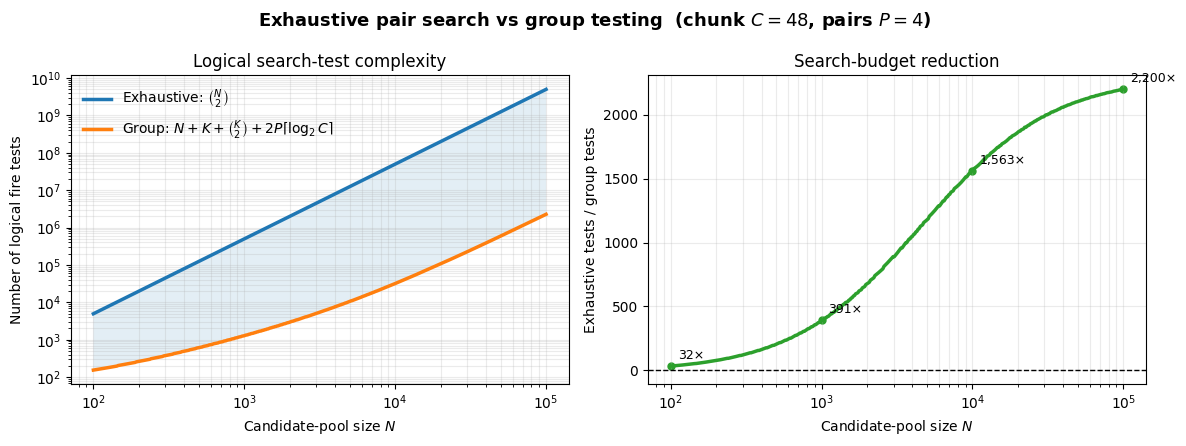

       N     exhaustive    group tests    reduction
     100          4,950            154        32.1×
   1,000        499,500          1,279       390.5×
  10,000     49,995,000         31,993     1,562.7×
 100,000  4,999,950,000      2,272,618     2,200.1×


In [1]:
# figure of complexity comparison:
# between exhaustive pairwise searching and group testing
# N = 100 -> 100,000
import numpy as np
import matplotlib.pyplot as plt

CHUNK = 48
N_PAIRS = 4
N = np.unique(np.logspace(2, 5, 400).astype(int))

exhaustive = N * (N - 1) / 2
n_chunks = np.ceil(N / CHUNK).astype(int)
single_scan = N
intra_scan = n_chunks
cross_scan = n_chunks * (n_chunks - 1) / 2
narrowing = 2 * N_PAIRS * np.ceil(np.log2(CHUNK))
group_testing = single_scan + intra_scan + cross_scan + narrowing
speedup = exhaustive / group_testing

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(N, exhaustive, lw=2.5, label=r"Exhaustive: $\binom{N}{2}$")
ax.loglog(N, group_testing, lw=2.5,
          label=r"Group: $N+K+\binom{K}{2}+2P\lceil\log_2 C\rceil$")
ax.fill_between(N, group_testing, exhaustive, alpha=0.12)
ax.set(title="Logical search-test complexity", xlabel="Candidate-pool size $N$",
       ylabel="Number of logical fire tests")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False)

ax = axes[1]
ax.semilogx(N, speedup, color="tab:green", lw=2.5)
ax.axhline(1, color="black", ls="--", lw=1)
ax.set(title="Search-budget reduction", xlabel="Candidate-pool size $N$",
       ylabel="Exhaustive tests / group tests")
ax.grid(True, which="both", alpha=0.25)

for n in (100, 1_000, 10_000, 100_000):
    i = np.abs(N - n).argmin()
    ax.scatter(N[i], speedup[i], color="tab:green", s=25)
    ax.annotate(f"{speedup[i]:,.0f}×", (N[i], speedup[i]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)

fig.suptitle(f"Exhaustive pair search vs group testing  (chunk $C={CHUNK}$, pairs $P={N_PAIRS}$)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"{'N':>8} {'exhaustive':>14} {'group tests':>14} {'reduction':>12}")
for n in (100, 1_000, 10_000, 100_000):
    k = int(np.ceil(n / CHUNK))
    ex = n * (n - 1) // 2
    gt = n + k + k * (k - 1) // 2 + 2 * N_PAIRS * int(np.ceil(np.log2(CHUNK)))
    print(f"{n:8,d} {ex:14,d} {gt:14,d} {ex / gt:11,.1f}×")

## Recursive group-testing algorithm

Let $\operatorname{fire}(S)=1$ iff $S$ contains a complete trigger pair.

$$
\begin{aligned}
&\operatorname{FindPairs}(S):\\
&\quad \mathbf{if}\ |S|<2\ \mathbf{or}\ \neg\operatorname{fire}(S),\ \mathbf{return}\ \varnothing\\
&\quad \mathbf{if}\ |S|=2,\ \mathbf{return}\ S\ \text{if confirmed, otherwise }\varnothing\\
&\quad (L,R)\leftarrow\operatorname{split}(S)\\
&\quad P\leftarrow\operatorname{FindPairs}(L)\cup\operatorname{FindPairs}(R)\\
&\quad U\leftarrow\{x:x\text{ occurs in a pair in }P\}\\
&\quad P\leftarrow P\cup\operatorname{FindCross}(L\setminus U,R\setminus U)\\
&\quad \mathbf{return}\ P
\end{aligned}
$$

$\operatorname{FindCross}$ recursively bisects the larger side, discards non-firing subsets, and confirms pairs when both sides contain one token.

# 